In [23]:
""" Perform EDA with a focus on descriptive analysis, text processing, time series, and publisher insights.
Analysis Components:
1. Descriptive Statistics:
•	Textual Lengths:
o	Calculate headline lengths (number of characters and words).
o	Provide summary statistics (mean, median, standard deviation) for headline lengths."""

import pandas as pd

# Load dataset
news_df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

news_df['headline_word_count'] = news_df['headline'].apply(lambda x: len(x.split()))
print(news_df['headline_word_count'].describe())

# Headline length analysis
news_df['headline_length'] = news_df['headline'].apply(len)
print(news_df['headline_length'].describe())

# Number of articles per publisher
articles_per_publisher = news_df['publisher'].value_counts()
print(articles_per_publisher)

count    1.407328e+06
mean     1.141671e+01
std      6.352997e+00
min      1.000000e+00
25%      7.000000e+00
50%      1.000000e+01
75%      1.300000e+01
max      7.700000e+01
Name: headline_word_count, dtype: float64
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
                      ...  
Matthew Ely               1
Frank Ochoa               1
Jeremie Capron            1
Marvin Dumont             1
Igor Gonta                1
Name: count, Length: 1034, dtype: int64


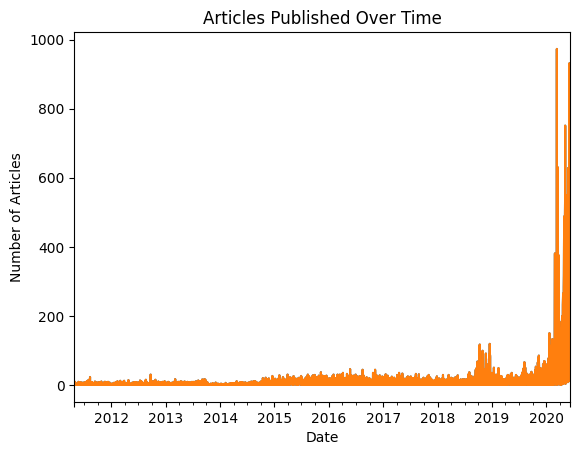

In [24]:
from matplotlib import pyplot as plt
import pandas as pd

""" •	Publication Date Trends:
o	Use date parsing to analyze publishing trends. """

news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce', utc=True)
news_data = news_df.dropna(subset=['date'])
news_data.set_index('date').resample('D').size().plot(kind='line')
news_data.set_index('date').resample('D').size().plot(kind='line')
plt.title("Articles Published Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.show()


In [25]:
""" 2. Text Analysis:
•	Sentiment Analysis:
o	Use libraries like TextBlob or nltk for sentiment scoring (positive, negative, neutral). """

from textblob import TextBlob

# Perform sentiment analysis
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity  # Polarity ranges [-1, 1]

news_df['sentiment'] = news_df['headline'].apply(get_sentiment)

# Sentiment distribution
print(news_df['sentiment'].describe())



count    1.407328e+06
mean     4.905657e-02
std      1.830652e-01
min     -1.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
Name: sentiment, dtype: float64


In [26]:
""" •	Topic Modeling:
o	Perform keyword extraction or topic modeling using gensim. """

%pip install -q gensim
from gensim import corpora
from gensim.models import LdaModel
# Tokenize the headlines
news_df['tokens'] = news_df['headline'].apply(lambda x: x.split())
# Create a dictionary and corpus for topic modeling
dictionary = corpora.Dictionary(news_df['tokens'])
corpus = [dictionary.doc2bow(text) for text in news_df['tokens']]


Note: you may need to restart the kernel to use updated packages.


C:\Users\Almazt\AppData\Local\Temp\ipykernel_17104\3170840974.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  news_data['date'].groupby(news_data['date'].dt.to_period('M')).size().plot(figsize=(12, 6), title="Articles Published Over Month")


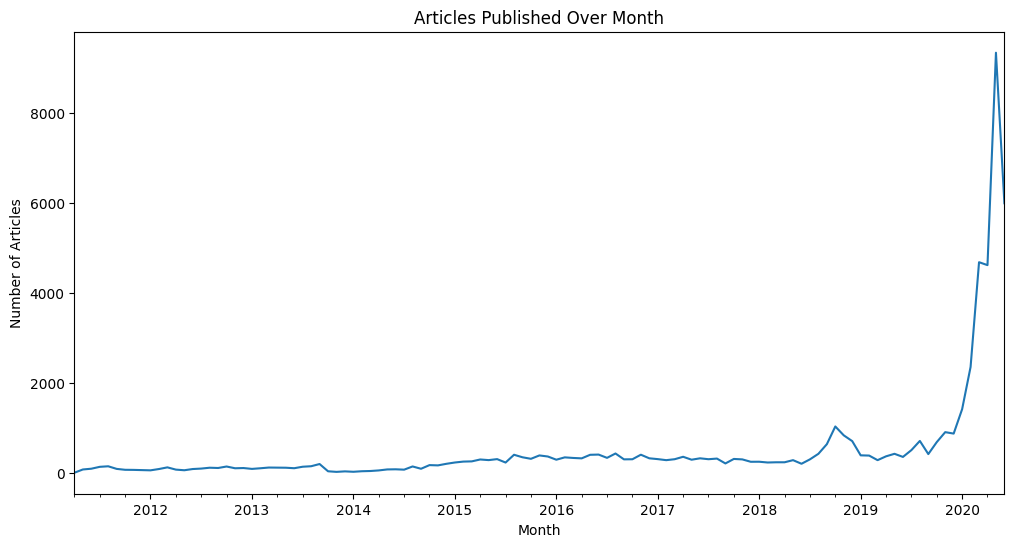

In [27]:
""" 3. Time Series Analysis:
•	Publication Frequency Over Time:
o	Plot a time series graph of article counts by day/week. """

news_data['date'].groupby(news_data['date'].dt.to_period('M')).size().plot(figsize=(12, 6), title="Articles Published Over Month")
plt.xlabel("Month")
plt.ylabel("Number of Articles")
plt.show()


In [28]:
import pandas as pd
news_data =  pd.read_csv("../data/raw/raw_analyst_ratings.csv")

In [29]:
news_data.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [30]:
import pandas as pd

# Download stock data for Apple (AAPL) from 2020-01-01 to the present
stock_data =  pd.read_csv("../data/raw/AAPL_historical_data.csv")

print("Display the first few rows of the data AAPL")
print(stock_data.head())

# Download stock data for Amazon (AMZN) from 2020-01-01 to the present
stock_data =  pd.read_csv("../data/raw/AMZN_historical_data.csv")

print("Display the first few rows of the data AMZN")
print(stock_data.head())

# Download stock data for Google (GOOG) from 2020-01-01 to the present
stock_data =  pd.read_csv("../data/raw/GOOG_historical_data.csv")

print("Display the first few rows of the data GOOG")
print(stock_data.head())

# Download stock data for Meta (META) from 2020-01-01 to the present
stock_data =  pd.read_csv("../data/raw/META_historical_data.csv")

print("Display the first few rows of the data META")
print(stock_data.head())

# Download stock data for Microsoft (MSFT) from 2020-01-01 to the present
stock_data =  pd.read_csv("../data/raw/MSFT_historical_data.csv")

print("Display the first few rows of the data MSFT")
print(stock_data.head())

# Download stock data for Nvidia (NVDA) from 2020-01-01 to the present
stock_data =  pd.read_csv("../data/raw/NVDA_historical_data.csv")

print("Display the first few rows of the data NVDA")
print(stock_data.head())

# Download stock data for Tesla (TSLA) from 2020-01-01 to the present
stock_data =  pd.read_csv("../data/raw/TSLA_historical_data.csv")

print("Display the first few rows of the data TSLA")
print(stock_data.head())

Display the first few rows of the data AAPL
         Date      Open      High       Low     Close  Adj Close     Volume  \
0  1980-12-12  0.128348  0.128906  0.128348  0.128348   0.098943  469033600   
1  1980-12-15  0.122210  0.122210  0.121652  0.121652   0.093781  175884800   
2  1980-12-16  0.113281  0.113281  0.112723  0.112723   0.086898  105728000   
3  1980-12-17  0.115513  0.116071  0.115513  0.115513   0.089049   86441600   
4  1980-12-18  0.118862  0.119420  0.118862  0.118862   0.091630   73449600   

   Dividends  Stock Splits  
0        0.0           0.0  
1        0.0           0.0  
2        0.0           0.0  
3        0.0           0.0  
4        0.0           0.0  
Display the first few rows of the data AMZN
         Date      Open      High       Low     Close  Adj Close      Volume  \
0  1997-05-15  0.121875  0.125000  0.096354  0.097917   0.097917  1443120000   
1  1997-05-16  0.098438  0.098958  0.085417  0.086458   0.086458   294000000   
2  1997-05-19  0.088021

In [31]:
import yfinance as yf

In [32]:
# Download stock data for Apple (AAPL) from 2020-01-01 to the present
stock_data = yf.download('AAPL', start='2020-01-01', end='2026-05-01')

# Display the first few rows of the data
print(stock_data.head())

# Download stock data for Amazon (AMZN) from 2020-01-01 to the present
stock_data = yf.download('AMZN', start='2020-01-01', end='2026-05-01')

# Display the first few rows of the data
print(stock_data.head())

# Download stock data for Google (GOOG) from 2020-01-01 to the present
stock_data = yf.download('GOOG', start='2020-01-01', end='2026-05-01')

# Display the first few rows of the data
print(stock_data.head())

# Download stock data for Meta (META) from 2020-01-01 to the present
stock_data = yf.download('META', start='2020-01-01', end='2026-05-01')

# Display the first few rows of the data
print(stock_data.head())

# Download stock data for Microsoft (MSFT) from 2020-01-01 to the present
stock_data = yf.download('MSFT', start='2020-01-01', end='2026-05-01')

# Display the first few rows of the data
print(stock_data.head())

# Download stock data for Nvidia (NVDA) from 2020-01-01 to the present
stock_data = yf.download('NVDA', start='2020-01-01', end='2026-05-01')

# Display the first few rows of the data
print(stock_data.head())

# Download stock data for Tesla (TSLA) from 2020-01-01 to the present
stock_data = yf.download('TSLA', start='2020-01-01', end='2026-05-01')

# Display the first few rows of the data
print(stock_data.head())

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: ConnectionError(MaxRetryError('HTTPSConnectionPool(host=\'fc.yahoo.com\', port=443): Max retries exceeded with url: / (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x000002094DCD2120>: Failed to resolve \'fc.yahoo.com\' ([Errno 11001] getaddrinfo failed)"))'))


Empty DataFrame
Columns: [(Adj Close, AAPL), (Close, AAPL), (High, AAPL), (Low, AAPL), (Open, AAPL), (Volume, AAPL)]
Index: []


Failed to get ticker 'AMZN' reason: Expecting value: line 1 column 1 (char 0)
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AMZN']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')


Empty DataFrame
Columns: [(Adj Close, AMZN), (Close, AMZN), (High, AMZN), (Low, AMZN), (Open, AMZN), (Volume, AMZN)]
Index: []


Failed to get ticker 'GOOG' reason: Expecting value: line 1 column 1 (char 0)
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['GOOG']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')


...

Empty DataFrame
Columns: [(Adj Close, MSFT), (Close, MSFT), (High, MSFT), (Low, MSFT), (Open, MSFT), (Volume, MSFT)]
Index: []


Failed to get ticker 'NVDA' reason: HTTPSConnectionPool(host='query2.finance.yahoo.com', port=443): Read timed out. (read timeout=10)
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['NVDA']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')


Empty DataFrame
Columns: [(Adj Close, NVDA), (Close, NVDA), (High, NVDA), (Low, NVDA), (Open, NVDA), (Volume, NVDA)]
Index: []


Failed to get ticker 'TSLA' reason: HTTPSConnectionPool(host='query2.finance.yahoo.com', port=443): Read timed out. (read timeout=10)
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['TSLA']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')


Empty DataFrame
Columns: [(Adj Close, TSLA), (Close, TSLA), (High, TSLA), (Low, TSLA), (Open, TSLA), (Volume, TSLA)]
Index: []


In [33]:
import pandas as pd

""" Descriptive Statistics:
•	Textual Lengths:
o	Calculate headline lengths (number of characters and words). """

# Example DataFrame initialization (adjust according to your actual data)
data = {
    'headline': ['Stock market crashes', 'Tech stock surges', 'Oil prices soar', 'Government announces new policy']
}

df = pd.DataFrame(data)

df['headline_length'] = df['headline'].apply(len)
print(df['headline_length'].describe())


count     4.000000
mean     20.750000
std       7.135592
min      15.000000
25%      16.500000
50%      18.500000
75%      22.750000
max      31.000000
Name: headline_length, dtype: float64


In [34]:
%pip install -q textblob
from textblob import TextBlob

""" Text Analysis:
•	Sentiment Analysis:
o	Use libraries like TextBlob or nltk for sentiment scoring (positive, negative, neutral). """

# from textblob import TextBlob

def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df['sentiment'] = df['headline'].apply(get_sentiment)


Note: you may need to restart the kernel to use updated packages.


In [35]:
""" • Topic Modeling:
o Perform keyword extraction or topic modeling using gensim. """

import gensim
from gensim import corpora
from gensim.models import LdaModel
import re

# 1. Simple cleaning function
def clean_text(text):
    text = re.sub(r'\s+', ' ', text) # Remove extra whitespace
    return text.lower().split()

# 2. Prepare Data

raw_headlines = news_df['headline'].astype(str).head(1000)
texts = [clean_text(h) for h in raw_headlines]

# 3. Create Dictionary and Corpus
dictionary = corpora.Dictionary(texts)
# Optional: Filter out words that appear in less than 2 documents or more than 50%
dictionary.filter_extremes(no_below=2, no_above=0.5) 

corpus = [dictionary.doc2bow(text) for text in texts]

# 4. Train LDA Model
lda_model = LdaModel(
    corpus=corpus, 
    id2word=dictionary, 
    num_topics=5, 
    random_state=42,
    passes=10,        # Number of iterations over the corpus
    alpha='auto'      # Learns the topic distribution per document
)

# 5. Display Topics
for idx, topic in lda_model.print_topics(-1):
    print(f"Topic {idx}: {topic}\n")


Topic 0: 0.031*"for" + 0.030*"agilent" + 0.028*"the" + 0.023*"of" + 0.023*"and" + 0.021*"technologies" + 0.021*"top" + 0.014*"benzinga's" + 0.014*"vs." + 0.011*"-"

Topic 1: 0.082*"agilent" + 0.070*"to" + 0.051*"on" + 0.046*"technologies" + 0.033*"pt" + 0.031*"raises" + 0.026*"maintains" + 0.025*"technologies," + 0.017*"morgan" + 0.016*"lowers"

Topic 2: 0.053*"vs" + 0.041*"agilent" + 0.038*"for" + 0.034*"eps" + 0.032*"stocks" + 0.024*"sales" + 0.022*"earnings" + 0.020*"to" + 0.020*"sees" + 0.020*"in"

Topic 3: 0.050*"the" + 0.038*"of" + 0.025*"market" + 0.025*"in" + 0.024*"shares" + 0.023*"to" + 0.021*"are" + 0.020*"trading" + 0.019*"a" + 0.017*"companies"

Topic 4: 0.060*"agilent" + 0.029*"for" + 0.025*"with" + 0.025*"on" + 0.024*"technologies" + 0.022*"of" + 0.022*"to" + 0.018*"announces" + 0.015*"in" + 0.015*"initiates"



In [36]:
""" Time Series Analysis:
•	Publication Frequency Over Time:
o	Plot a time series graph of article counts by day/week. """

# df['date'].groupby(df['date'].dt.to_period('M')).count().plot()
print(df.columns)
df.columns = df.columns.str.strip()

Index(['headline', 'headline_length', 'sentiment'], dtype='object')


In [37]:
import re

""" Publisher Analysis:
•	Top Publishers:
o	Identify publishers contributing most to the news feed.
•	Domain Analysis:
o	Extract domains from email-like publisher names using regex: """

def extract_domain(publisher):
    if not isinstance(publisher, str):
        return publisher
    match = re.search(r'@([\w.-]+\.\w+)', publisher)
    return match.group(1) if match else publisher

news_df['domain'] = news_df['publisher'].apply(extract_domain)
print(news_df['domain'].value_counts())

domain
Paul Quintaro            228373
Lisa Levin               186979
Benzinga Newsdesk        150484
Charles Gross             96732
Monica Gerson             82380
                          ...  
Fred Wilson                   1
Union Square Ventures         1
Sumit Mehta                   1
David Wenger                  1
ProactiveInvestors            1
Name: count, Length: 1024, dtype: int64


In [38]:


""" # Publication date trends
news_df['date'] = pd.to_datetime(news_df['date'])
articles_over_time = news_df['date'].value_counts().sort_index()

articles_over_time.plot(title="Articles Published Over Time", figsize=(10, 6)) """


' # Publication date trends\nnews_df[\'date\'] = pd.to_datetime(news_df[\'date\'])\narticles_over_time = news_df[\'date\'].value_counts().sort_index()\n\narticles_over_time.plot(title="Articles Published Over Time", figsize=(10, 6)) '